                                                               **NIVEL 1.**
"EJERCICIO 1": Importa como un DataFrame el archivo sprint10.xlsx.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import statistics as sts
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta

In [4]:
df_original = pd.read_excel("sprint10.xlsx",header=3, index_col= 0)     # header = 3: la fila que contiene los nombres reales de las columnas está en la posición 4 del Excel.
df = df_original.copy()                                                 # index_col = 0: la primera columna es un identificador secuencial que quiero utilizar como índice del DataFrame, evitando tener una columna redundante. 
df

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,25161375F,Espanya,Sevilla,1,6,1951,D,1.216 €,NaN,1.0,Grup B
996,Joan,García,52145541P,Espanya,Sevilla,11,4,1959,H,971 €,NaN,1.0,Grup A
997,Laia,Ferrer Martínez,69760120X,Espanya,Barcelona,11,11,1980,D,682 €,NaN,1.0,Grup A
998,Jordi,García,82947791W,Espanya,Barcelona,23,5,1984,H,1.699 €,1.0,NaN,Grup C


1.1 - Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.

1.2 - Muestra las primeras 10 filas.

Adicionalmente, realiza un print donde compruebe que el DNI sólo tiene valores únicos.

In [5]:
df = df.sort_values(["País d'origen", 'Ciutat'])
df.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
871,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
281,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
435,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
444,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
487,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


In [6]:
print(df['DNI'].is_unique)          # otra opción sería: print(df['DNI'].duplicated().sum()==0)

True


"EJERCICIO 2": Crea una columna que sea el nombre completo.

In [7]:
df['Nom_complet']= (df['Nom'] + ' ' + df['Cognoms'])
df

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom_complet
21,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,Mia Schneider Fischer
154,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer
224,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider
278,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B,Mia Fischer
602,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D,Jonas Schneider
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,Emily,Taylor Jones,89577876S,Regne Unit,Manchester,28,3,1958,D,2.033 €,NaN,1.0,Grup B,Emily Taylor Jones
728,George,Brown Jones,57441590Y,Regne Unit,Manchester,27,12,1979,H,1.130 €,1.0,NaN,Grup A,George Brown Jones
751,Olivia,Brown Brown,58204038A,Regne Unit,Manchester,28,8,1952,A,1.023 €,NaN,1.0,Grup A,Olivia Brown Brown
854,Isla,Jones Brown,28367234K,Regne Unit,Manchester,28,3,1999,D,1.197 €,NaN,1.0,Grup A,Isla Jones Brown


2.1- Crea una columna si la persona ha nacido en España o no.

In [8]:
df["País d'origen"].unique()              # Para ver el nombre de los países 

array(['Alemanya', 'Argentina', 'Colòmbia', 'Espanya', 'França', 'Itàlia',
       'Marroc', 'Mèxic', 'Portugal', 'Regne Unit'], dtype=object)

In [9]:
df['Nascuda_Espanya'] = np.where(df["País d'origen"]== 'Espanya','Si','No')            # Otra opción: df['Nascuda_Espanya'] = (df["País d'origen"] == 'Espanya')

df.loc[df["País d'origen"] == "Espanya"]

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom_complet,Nascuda_Espanya
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A,Clara Sánchez Martínez,Si
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A,Toni Sánchez García,Si
9,Toni,Martínez,14219925Z,Espanya,Barcelona,16,5,1964,H,891 €,NaN,1.0,Grup A,Toni Martínez,Si
10,Oriol,Sánchez,40695825B,Espanya,Barcelona,27,7,1965,H,1.250 €,NaN,1.0,Grup A,Oriol Sánchez,Si
13,Toni,Castells Romero,74222289K,Espanya,Barcelona,13,4,1961,H,1.438 €,NaN,1.0,Grup B,Toni Castells Romero,Si
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
944,Laia,Sánchez,42807414J,Espanya,València,17,7,1967,D,2.255 €,NaN,1.0,Grup C,Laia Sánchez,Si
949,Núria,Martínez Ferrer,38147748A,Espanya,València,4,11,1976,D,1.028 €,NaN,1.0,Grup A,Núria Martínez Ferrer,Si
958,Oriol,Sánchez García,48749091Z,Espanya,València,16,7,1965,H,1.273 €,NaN,1.0,Grup A,Oriol Sánchez García,Si
961,Clara,Romero García,29019539A,Espanya,València,8,2,1989,D,1.246 €,1.0,NaN,Grup A,Clara Romero García,Si


2.2- Pone el DNI como índice del DataFrame (nombres de filas).

In [10]:
df = df.set_index('DNI')                      # Coloca el campo como índice 
df.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom_complet,Nascuda_Espanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No


2.3- Sustituye el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.

In [11]:
df = df.rename(columns={'Dia de Naixement':'Dia', 'Mes de Naixement':'Mes', 'Any de Naixement':'Any'})
df.head(0)

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom_complet,Nascuda_Espanya
DNI,,,,,,,,,,,,,,


2.4- Sustituye a H por Hombre, D por Mujer, A por Otros y NC por un dato faltante (enano/null/na).

In [12]:
df["Gènere"].unique()           # Ver los valores reales que tiene el campo

array(['A', 'D', 'H', 'NC'], dtype=object)

In [13]:
df['Gènere']= df['Gènere'].replace({'H':'Home', 'D':'Dona', 'A':'Altres', 'NC':np.nan })      # np.nan refleja dato real faltante en Pandas y no cadena de texto NaN

df = df[['Nom', 'Cognoms', 'Nom_complet', "País d'origen", 'Ciutat', 'Nascuda_Espanya','Dia', 'Mes', 'Any', 
         'Gènere', 'Salari mensual', 'Fills', 'No Fills', 'Grup Professional']]
df

,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Nascuda_Espanya,Dia,Mes,Any,Gènere,Salari mensual,Fills,No Fills,Grup Professional
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,No,22,10,1976,Altres,951 €,NaN,1.0,Grup A
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,No,2,2,1958,Dona,1.769 €,1.0,NaN,Grup B
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,No,23,10,2005,Dona,2.013 €,NaN,1.0,Grup B
21390098Z,Mia,Fischer,Mia Fischer,Alemanya,Berlín,No,11,8,1950,Dona,1.557 €,1.0,NaN,Grup B
44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,No,22,11,1985,Home,2.754 €,1.0,NaN,Grup D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89577876S,Emily,Taylor Jones,Emily Taylor Jones,Regne Unit,Manchester,No,28,3,1958,Dona,2.033 €,NaN,1.0,Grup B
57441590Y,George,Brown Jones,George Brown Jones,Regne Unit,Manchester,No,27,12,1979,Home,1.130 €,1.0,NaN,Grup A
58204038A,Olivia,Brown Brown,Olivia Brown Brown,Regne Unit,Manchester,No,28,8,1952,Altres,1.023 €,NaN,1.0,Grup A


"Ejercicio 3": Junta las columnas Hijos y No Hijos en una sola columna, utilizando el método .apply() y definiendo una función que resuelva el problema. La columna nueva debe llamarse "Hijos" y tomar los valores "Sí" o "No".

In [14]:
for col in ['Fills', 'No Fills']:             # Compruebo valores reales de ambos campos
    print(col)
    print(df[col].unique())
    print()                 


Fills
[nan  1.]

No Fills
[ 1. nan]



In [15]:
def analizar_info(row):
    if row['Fills'] == 1:              # Valoro solo en Fills porque ya me da la info que necesito
        return 'Si'
    else:
        return 'No'

df['Fills'] = df.apply(analizar_info, axis=1)     

df = df.drop(columns=['No Fills'])
df.head(3)

,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Nascuda_Espanya,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,No,22,10,1976,Altres,951 €,No,Grup A
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,No,2,2,1958,Dona,1.769 €,Si,Grup B
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,No,23,10,2005,Dona,2.013 €,No,Grup B


In [16]:
df['Fills'].unique()                      # Verifico los valores reales del nuevo campo

array(['No', 'Si'], dtype=object)

"Ejercicio 4": Crea una tabla resumen que permita ver el sueldo medio, medio, mínimo y máximo por Género.
Ordena la tabla en función del sueldo medio.

In [17]:
df['Salari mensual'].unique()[:10]          # Compruebo el tipo de datos

array(['951 €', '1.769 €', '2.013 €', '1.557 €', '2.754 €', '1.370 €',
       '1.314 €', '2.464 €', '2.035 €', '2.042 €'], dtype=object)

In [18]:
df['Salari mensual'] = df['Salari mensual'].str.replace('€', '').str.replace('.', '')       # Se elimina € y el .
df['Salari mensual'] 

DNI
28973553Z     951 
37399141L    1769 
37368317L    2013 
21390098Z    1557 
44060014R    2754 
             ...  
89577876S    2033 
57441590Y    1130 
58204038A    1023 
28367234K    1197 
82046699J    1405 
Name: Salari mensual, Length: 1000, dtype: object

In [19]:
df['Salari mensual'] = df['Salari mensual'].str.strip()        # Elimina el espacio final del símbolo

In [20]:
df['Salari mensual'] = pd.to_numeric(df['Salari mensual'])      # Convierte los datos a numéricos

In [21]:
df_salario_genero = df.groupby("Gènere", dropna = False)["Salari mensual"].agg(["mean", "median", "min", "max"]).round(2)      # ["Salari mensual"] genero una serie, de lo contrario [[]] genera un DataFrame con columnas MultiIndex y no puedo ordenar por valores de columnas.
df_salario_genero = df_salario_genero.sort_values(['mean'])                                        # dropna = False contempla los valores de Nan.
df_salario_genero

,mean,median,min,max
Gènere,,,,
Dona,1469.44,1361.5,665,3021
NaN,1568.87,1443.0,758,2969
Altres,1626.59,1545.0,703,3175
Home,1643.25,1531.0,737,3356


"Ejercicio 5": Crea una tabla resumen con el salario medio por género (filas) y país de origen (columnas).
Añade las medias a los márgenes de la mesa.
(EXTRA): Aplica formato condicional en la tabla para ver en un color más intenso los valores más elevados

In [88]:
df_salario_pais = pd.pivot_table(
       df,
       values= "Salari mensual",
       index="Gènere",
       columns= "País d'origen",
       aggfunc= "mean",
       margins= True,            # Sin "" para que devuelva un bool no un stirng.
       margins_name= "Mitjanes").round (2)
df_salario_pais.style.background_gradient().format("{:.2f}")

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Mitjanes
Gènere,,,,,,,,,,,
Altres,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Dona,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Home,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mitjanes,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


"Ejercicio 6": Crea una nueva columna que sea la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año. Utilizando esta columna crea una función que dada una fecha, te calcule la edad actual a día de hoy.
Utiliza la función que acabas de crear para generar una columna nueva en DataFrame con la edad actual.

In [23]:
df['Fecha'] = pd.to_datetime(df[['Any', 'Mes', 'Dia']].rename(columns={'Any': 'Year', 'Mes':'Month', 'Dia': 'Day'}))
df['Fecha']

DNI
28973553Z   1976-10-22
37399141L   1958-02-02
37368317L   2005-10-23
21390098Z   1950-08-11
44060014R   1985-11-22
               ...    
89577876S   1958-03-28
57441590Y   1979-12-27
58204038A   1952-08-28
28367234K   1999-03-28
82046699J   1997-05-19
Name: Fecha, Length: 1000, dtype: datetime64[ns]

In [ ]:
def calcular_edad(fecha_nacimiento):
    '''Calcula la edad en años a partir de la fecha de nacimiento,
        teniendo en cuenta la fecha actual.'''
    
    ano_nacimiento = fecha_nacimiento.year
    mes_nacimiento = fecha_nacimiento.month
    dia_nacimiento = fecha_nacimiento.day

    fecha_actual = datetime.now()
    
    ano_actual = fecha_actual.year
    mes_actual = fecha_actual.month
    dia_actual = fecha_actual.day

    edad_temporal = ano_actual - ano_nacimiento

    if mes_actual > mes_nacimiento:
        return edad_temporal
    elif mes_actual < mes_nacimiento:
        return edad_temporal - 1
    else:
        if dia_actual >= dia_nacimiento:
            return edad_temporal
        else:
            return edad_temporal - 1 


df['Edat'] = (df['Fecha'].apply(calcular_edad))
df.head(3)

,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Nascuda_Espanya,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Fecha,Edat
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,No,22,10,1976,Altres,951,No,Grup A,1976-10-22,49
37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,No,2,2,1958,Dona,1769,Si,Grup B,1958-02-02,68
37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,No,23,10,2005,Dona,2013,No,Grup B,2005-10-23,20


                                                       **NIVEL 2.**
"EJERCICIO 1": Utilizando el siguiente DataFrame, adjunta la columna "Incremento" al dataframe del nivel anterior.

Actualiza la columna salario en función de los porcentajes que se adjuntan. No modifiques manualmente los incrementos, escribe código Python para realizar las conversiones necesarias.

In [28]:
df_increment = pd.DataFrame({"Grup":["Grup A","Grup B","Grup C", "Grup D" ] , "Increment":["5%","3,5%","2%","8%"]})
df_increment

,Grup,Increment
0,Grup A,5%
1,Grup B,"3,5%"
2,Grup C,2%
3,Grup D,8%


In [31]:
df_aux = df.reset_index()                  # Para devolver DNI como columna y no perder el valor luego en el merge.
df_aux.head()

,DNI,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Nascuda_Espanya,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Fecha,Edat
0,28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,No,22,10,1976,Altres,951,No,Grup A,1976-10-22,49
1,37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,No,2,2,1958,Dona,1769,Si,Grup B,1958-02-02,68
2,37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,No,23,10,2005,Dona,2013,No,Grup B,2005-10-23,20
3,21390098Z,Mia,Fischer,Mia Fischer,Alemanya,Berlín,No,11,8,1950,Dona,1557,Si,Grup B,1950-08-11,75
4,44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,No,22,11,1985,Home,2754,Si,Grup D,1985-11-22,40


In [32]:
df_nivel2 = pd.merge(df_aux, df_increment, left_on='Grup Professional', right_on='Grup', how= 'left')

df_nivel2 = df_nivel2.drop(columns=['Grup'])
df_nivel2.head()

,DNI,Nom,Cognoms,Nom_complet,País d'origen,Ciutat,Nascuda_Espanya,Dia,Mes,Any,Gènere,Salari mensual,Fills,Grup Professional,Fecha,Edat,Increment
0,28973553Z,Mia,Schneider Fischer,Mia Schneider Fischer,Alemanya,Berlín,No,22,10,1976,Altres,951,No,Grup A,1976-10-22,49,5%
1,37399141L,Laura,Schneider Fischer,Laura Schneider Fischer,Alemanya,Berlín,No,2,2,1958,Dona,1769,Si,Grup B,1958-02-02,68,"3,5%"
2,37368317L,Lea,Schneider Schneider,Lea Schneider Schneider,Alemanya,Berlín,No,23,10,2005,Dona,2013,No,Grup B,2005-10-23,20,"3,5%"
3,21390098Z,Mia,Fischer,Mia Fischer,Alemanya,Berlín,No,11,8,1950,Dona,1557,Si,Grup B,1950-08-11,75,"3,5%"
4,44060014R,Jonas,Schneider,Jonas Schneider,Alemanya,Berlín,No,22,11,1985,Home,2754,Si,Grup D,1985-11-22,40,8%


In [33]:
df_nivel2['Increment'].unique()            # Verificar tipo de dato.

array(['5%', '3,5%', '8%', '2%'], dtype=object)

In [34]:
df_nivel2['Increment'] = df_nivel2['Increment'].str.replace('%','').str.replace(',','.')       # Limpieza.

df_nivel2['Increment'] = pd.to_numeric(df_nivel2['Increment'])       # Conversión.

In [35]:
df_nivel2['Salari mensual'] = (df_nivel2['Salari mensual']*(1+ (df_nivel2['Increment']/100))).round(2)
df_nivel2['Salari mensual'].head()

0     998.55
1    1830.92
2    2083.46
3    1611.50
4    2974.32
Name: Salari mensual, dtype: float64

"EJERCICIO 2": Utilizando un bucle, exporta en 4 archivos (formato .xlsx o .csv) los datos de cada Grupo Profesional.
Exporta un 5º DataFrame en formato .xlsx o .csv que contenga cuántos trabajadores hay por cada Grupo Profesional, cuál es su sueldo medio y cuál es su edad media.

In [86]:
for grup in df_nivel2['Grup Professional'].unique():
    df_grup = df_nivel2.loc[df_nivel2['Grup Professional'] == grup, :]
    nombre_fichero = grup.replace(' ', '')
    df_grup.to_csv(f'datos_{nombre_fichero}.csv', index=False, sep= ';', encoding='utf-8')

df_grup_prof = df_nivel2.groupby('Grup Professional').agg(
    Treballadors=('Grup Professional', 'count'),         # Se nombra diretamente la nueva columna
    Salari_mig=('Salari mensual', 'mean'),
    Edat_mitjana=('Edat', 'mean')).round(2)
df_grup_prof

df_grup_prof.to_excel('datos_grups.xlsx')
print(df_grup_prof)

                   Treballadors  Salari_mig  Edat_mitjana
Grup Professional                                        
Grup A                      490     1213.32         49.45
Grup B                      318     1724.55         48.20
Grup C                      137     2289.19         51.24
Grup D                       55     3100.82         45.27


                                                        **NIVEL 3.**
"EJERCICIO 1": Crea una función que tome un dataframe como parámetro de entrada.
La función debe crear (y exportar) un gráfico automáticamente para cada columna del dataframe

C:\Users\HMGONZALEZ\AppData\Local\Temp\ipykernel_3284\1881388926.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  serie_fecha = pd.to_datetime(df[columna])


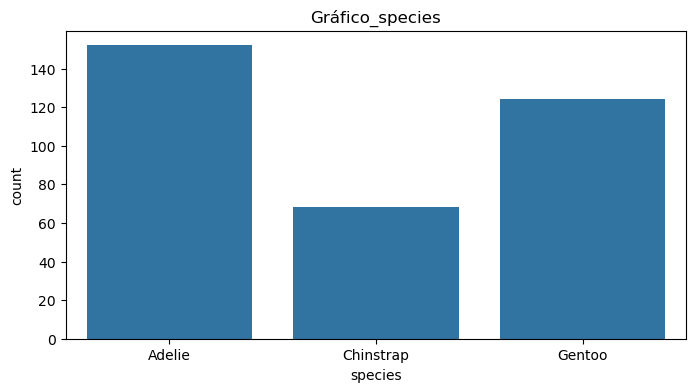

C:\Users\HMGONZALEZ\AppData\Local\Temp\ipykernel_3284\1881388926.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  serie_fecha = pd.to_datetime(df[columna])


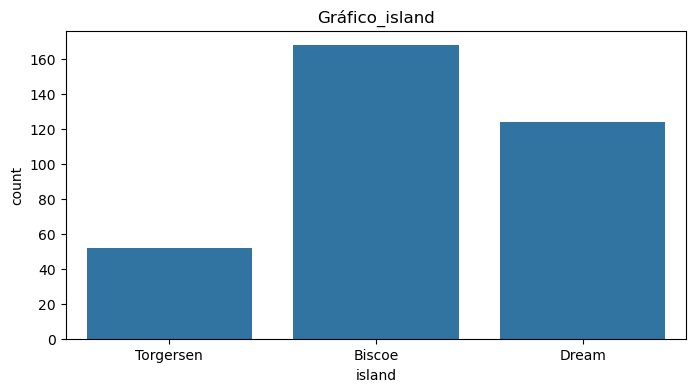

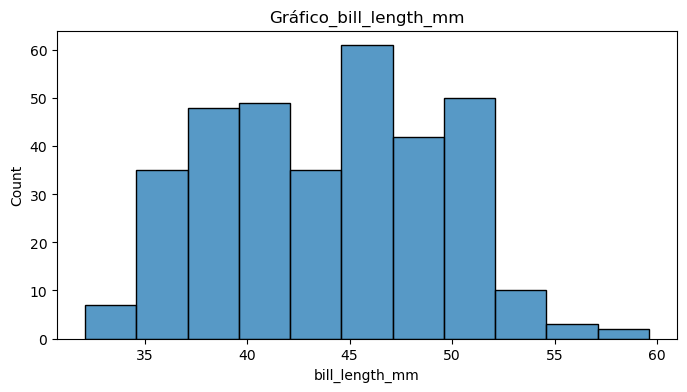

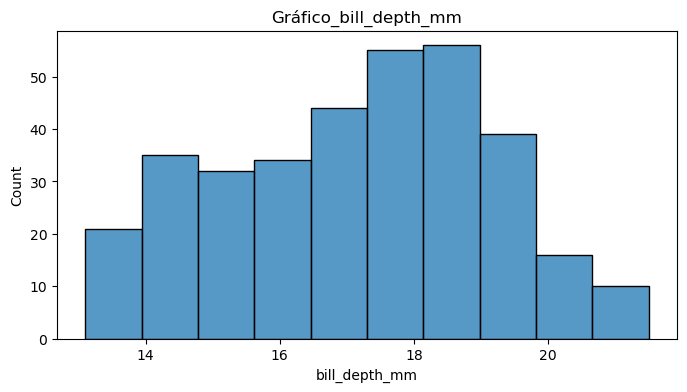

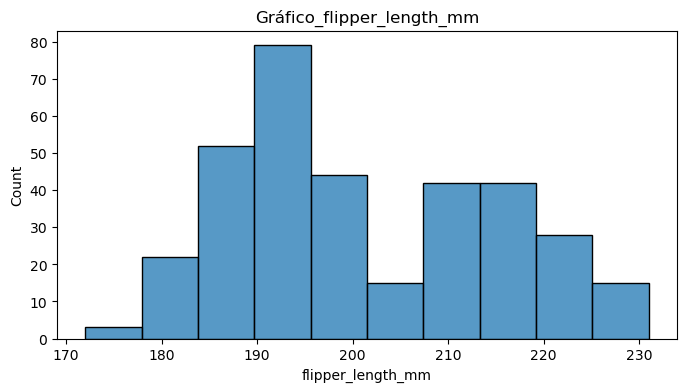

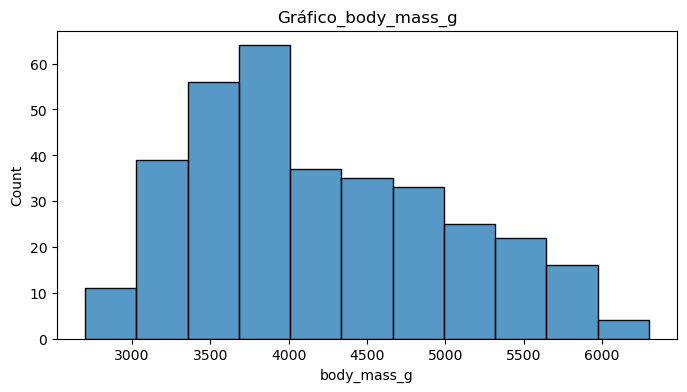

C:\Users\HMGONZALEZ\AppData\Local\Temp\ipykernel_3284\1881388926.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  serie_fecha = pd.to_datetime(df[columna])


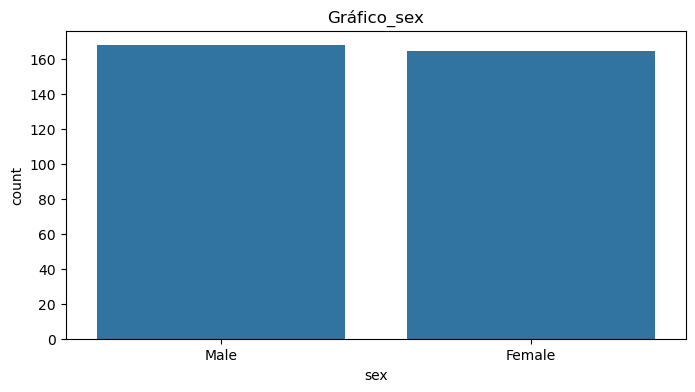

In [ ]:
def crear_exportar_grafico(df):

    '''Crea un gráfico para cada columna de un DataFrame.
       Genera un histograma para las variables numéricas, un gráfico de barras
       para las variables categóricas y un gráfico de barras con la frecuencia
       de los años para las variables de tipo fecha.
       Muestra un gráfico por cada columna del DataFrame.'''

    for columna in df.columns:

        plt.figure(figsize=(8,4))

        serie_fecha = None

        if pd.api.types.is_numeric_dtype(df[columna]):

            sns.histplot(data=df, x=columna)

        elif pd.api.types.is_datetime64_dtype(df[columna]):

            serie_fecha = df[columna]

        elif pd.api.types.is_object_dtype(df[columna]) or pd.api.types.is_string_dtype(df[columna]):

            try:
                serie_fecha = pd.to_datetime(df[columna])

            except Exception:

                sns.countplot(data=df, x=columna)

        else:

            sns.countplot(data=df, x=columna)

        if serie_fecha is not None:

            year = serie_fecha.dt.year
            year.value_counts().plot(kind='bar')

        plt.title(f'Gráfico_{columna}')
        #plt.savefig(f'grafico_{columna}.png')
        #plt.close()
        plt.show()              # Lo utilizo para mostrar el resultado porque en realidad se utiliza savefig  y close()

penguins = sns.load_dataset("penguins")

crear_exportar_grafico(penguins)

"EJERCICIO 2": Nos interesa visitar todas las principales ciudades de España recorriendo la mínima distancia posible.

In [62]:
df_nivel3 = pd.read_excel("matriu_distancies.xlsx", index_col=0)
df_nivel3

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Palma,Las Palmas de Gran Canaria,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,206.0,2175.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,260.0,1874.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,791.0,1355.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,377.0,2001.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,695.0,1406.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,372.0,1723.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Palma,206.0,260.0,791.0,377.0,695.0,372.0,NaN,2093.0,621.0,303.0,671.0,664.0,1000.0,820.0,204.0
Las Palmas de Gran Canaria,2175.0,1874.0,1355.0,2001.0,1406.0,1723.0,2093.0,NaN,2022.0,1792.0,1470.0,1790.0,1682.0,1925.0,2168.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,621.0,2022.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,303.0,1792.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0


In [63]:
df_nivel3 = df_nivel3.drop(index=['Palma', 'Las Palmas de Gran Canaria'], columns=['Palma', 'Las Palmas de Gran Canaria'])
df_nivel3.head()

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0


In [ ]:
def calcular_ruta(df, ciudad_origen):
    '''Calcula una ruta aproximada visitando siempre la ciudad no visitada
    más cercana a partir de una ciudad de origen.
    Devuelve la lista con el orden del trayecto y la distancia total recorrida.'''
    
    recorrido = [ciudad_origen]
    distancia = 0
    ciudad_actual = ciudad_origen

    while len(recorrido) < len(df):
        fila = df.loc[ciudad_actual]
        fila_filtrada = fila.drop(recorrido)
        siguiente_ciudad = fila_filtrada.idxmin()
        distancia_min = fila_filtrada.min()
        recorrido.append(siguiente_ciudad)
        distancia += distancia_min
        ciudad_actual= siguiente_ciudad
    return recorrido, distancia 

ruta, distancia = calcular_ruta(df_nivel3, 'Barcelona')
print(ruta)
print(f'La distancia total recorrida sería {distancia} km.')

len(ruta) == len(df_nivel3)   # Validar que se hayan visitado todas las ciudades.

['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Valladolid', 'Gijón', 'Bilbao', 'Vigo']
La distancia total recorrida sería 2778.0 km.


True

In [82]:
def obtener_mejor_ciudad (df):

    '''Busca la ciudad de origen que produce la ruta más corta
        utilizando el criterio de ciudad más cercana.'''
     
    ciudad_inicial = df.index[0]
    ruta, mejor_distancia = calcular_ruta(df, ciudad_inicial)

    mejor_ciudad = ciudad_inicial
    mejor_ruta = ruta 

    for ciudad in df.index[1:]:
        ruta, distancia = calcular_ruta(df, ciudad)
        if distancia < mejor_distancia:
            mejor_ciudad = ciudad
            mejor_distancia = distancia
            mejor_ruta = ruta
    return mejor_ciudad, mejor_distancia, mejor_ruta   

mejor_ciudad, mejor_distancia, mejor_ruta = obtener_mejor_ciudad(df_nivel3)

print(mejor_ciudad)
print(mejor_distancia)
print(mejor_ruta)     

Barcelona
2778.0
['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Valladolid', 'Gijón', 'Bilbao', 'Vigo']
